## CMPINF 2100 Week 09
### What does LINEAR actually mean???

We use the phrase LINEAR MODEL or LINEAR REGRESSION all the time...but what does that really mean???

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

### What do you think linear means?

When most people hear LINEAR REGRESSION they think "best fit lines". They think a straight line between the output and the input.

But, you know now that the MODEL is actually predicting the AVERAGE OUTPUT!!!

So does LINEAR means the AVERAGE OUTPUT is LINEARLY RELATED to the INPUT???

The math notation for the conventional LINEAR MODEL:

$$\mu = \beta_0 + \beta_1 \times x $$

But...what if we instead **PREPROCESSED** OR TRANSFORMED the input through a NON-LINEAR transformation function

For example, let's define a NEW COLUMN `s` which is equal to the SIN(X) or the SINE FUNCTION applied to the input x.

The math notation looks like:

$$\mu = \beta_0 + \beta_1 \times s $$

The FAILURE depends on the INPUT!!! Or, the FEATURE is a FUNCTION of the INPUT!!!

$$\mu = \beta_0 + \beta_1 \times \sin(x) $$

Formally, the DEFINITION of LINEAR has **NOTHING** to do with the RELATIONSHIP between the TREND (AVERAGE OUTPUT) and the INPUT!!!

Linear means the TREND is LINEARLY related to the UNKNOWN regression coefficients!!!

Let's use simulated data to demonstrate all of the ASSUMPTIONS of the linear model just as we did in the previous example.

## Make data

we will create this model here $$\mu = \beta_0 + \beta_1 \times \sin(x) $$

To make the data we need to specify the coefficients and the sigma of the linear model

In [2]:
b0_sin = 0.25

b1_sin = -2.25

sigma_sin = 0.1

Generate input values from negative Pi to positive Pi

In [3]:
df_sin = pd.DataFrame({'x': np.linspace(-3.14159, 3.14159, num=25)})

In [4]:
df_sin

,x
0,-3.141590
1,-2.879791
2,-2.617992
3,-2.356192
4,-2.094393
5,-1.832594
6,-1.570795
7,-1.308996
8,-1.047197
9,-0.785398


The TREND or AVERAGE OUTPUT is a function of the INPUT!!!

In [5]:
df_sin['trend'] = b0_sin + b1_sin * np.sin(df_sin.x)

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


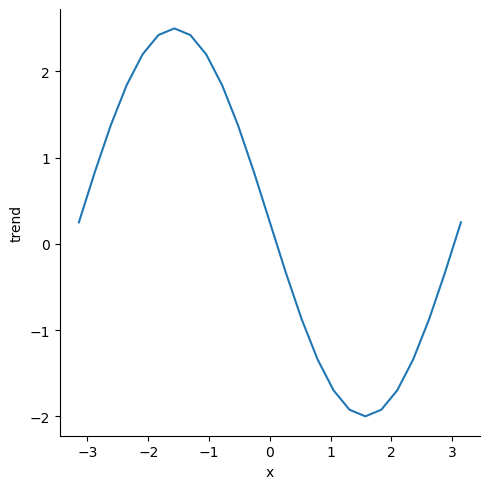

In [6]:
sns.relplot( data = df_sin, x='x', y='trend', kind='line')
plt.show()

Observation of the OUTPUT are NORMALLY distributed **GIVEN** the TREND!!!

If we know the TREND we know EVERYTHING about the distribution ASSUMED by the linear model!!

Use the random number generator to GENERATE the random outputs

In [7]:
rg = np.random.default_rng(2100)

In [8]:
df_sin['y'] = rg.normal(loc = df_sin.trend.to_numpy(),
                       scale=sigma_sin,
                       size=df_sin.shape[0])

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


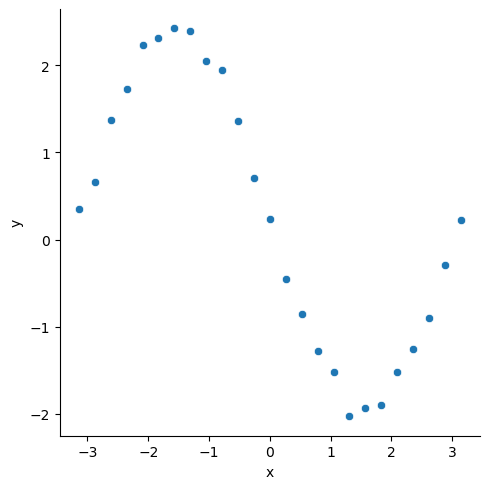

In [9]:
sns.relplot( data = df_sin, x='x', y='y')
plt.show()

The above data were generated from a LINEAR MODEL that satisfies **ALL** assumptions of the linear model!!!
To see that this is indeed a linear model, let's create the FEATURE `s` in the DataFrame

In [10]:
df_sin['s'] = np.sin( df_sin.x )

Now visualize the relationship between the random OUTPUT and the FEATURE derived from the input

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


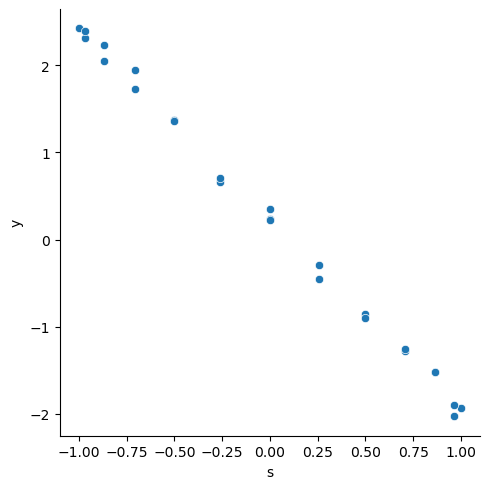

In [11]:
sns.relplot( data = df_sin, x='s', y='y')
plt.show()

## Simulation

Let's use the same simulation procedure as the previous example to reinforce the ASSUMPTION of the linear model!!

We need a funciton that calculate the TREND for a given INPUT and INTERCEPT and SLOPE. Which then randomly generate outputs around the TREDN for a given SIGMA value

In [12]:
def generate_lm_sin(rid, xuse, b0, b1, sigma_use):
    res_df = pd.DataFrame({'x':xuse})
    res_df['trend'] = b0 + b1 * np.sin( res_df.x )
    res_df['y'] = rg.normal( loc=res_df.trend.to_numpy(),
                            scale=sigma_use,
                           size=res_df.shape[0])
    res_df['rep_id'] = rid
    return res_df

In [14]:
generate_lm_sin( 0, df_sin.x, b0_sin, b1_sin, sigma_sin ).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       25 non-null     float64
 1   trend   25 non-null     float64
 2   y       25 non-null     float64
 3   rep_id  25 non-null     int64  
dtypes: float64(3), int64(1)
memory usage: 928.0 bytes


Replicate the process 9 times

In [15]:
study_9_list = []
for ix in range(9):
    study_9_list.append( generate_lm_sin( ix, df_sin.x,
                                         b0_sin, b1_sin,
                                         sigma_sin))

In [16]:
study_9_df = pd.concat( study_9_list, ignore_index=True )

In [17]:
study_9_df

,x,trend,y,rep_id
0,-3.141590,0.250006,0.317971,0
1,-2.879791,0.832348,0.875492,0
2,-2.617992,1.375004,1.550523,0
3,-2.356192,1.840993,1.783411,0
4,-2.094393,2.198559,2.201438,0
...,...,...,...,...
220,2.094393,-1.698559,-1.767417,8
221,2.356192,-1.340993,-1.346338,8
222,2.617992,-0.875004,-1.150933,8
223,2.879791,-0.332348,-0.179303,8


Visualize the replications via a facets

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


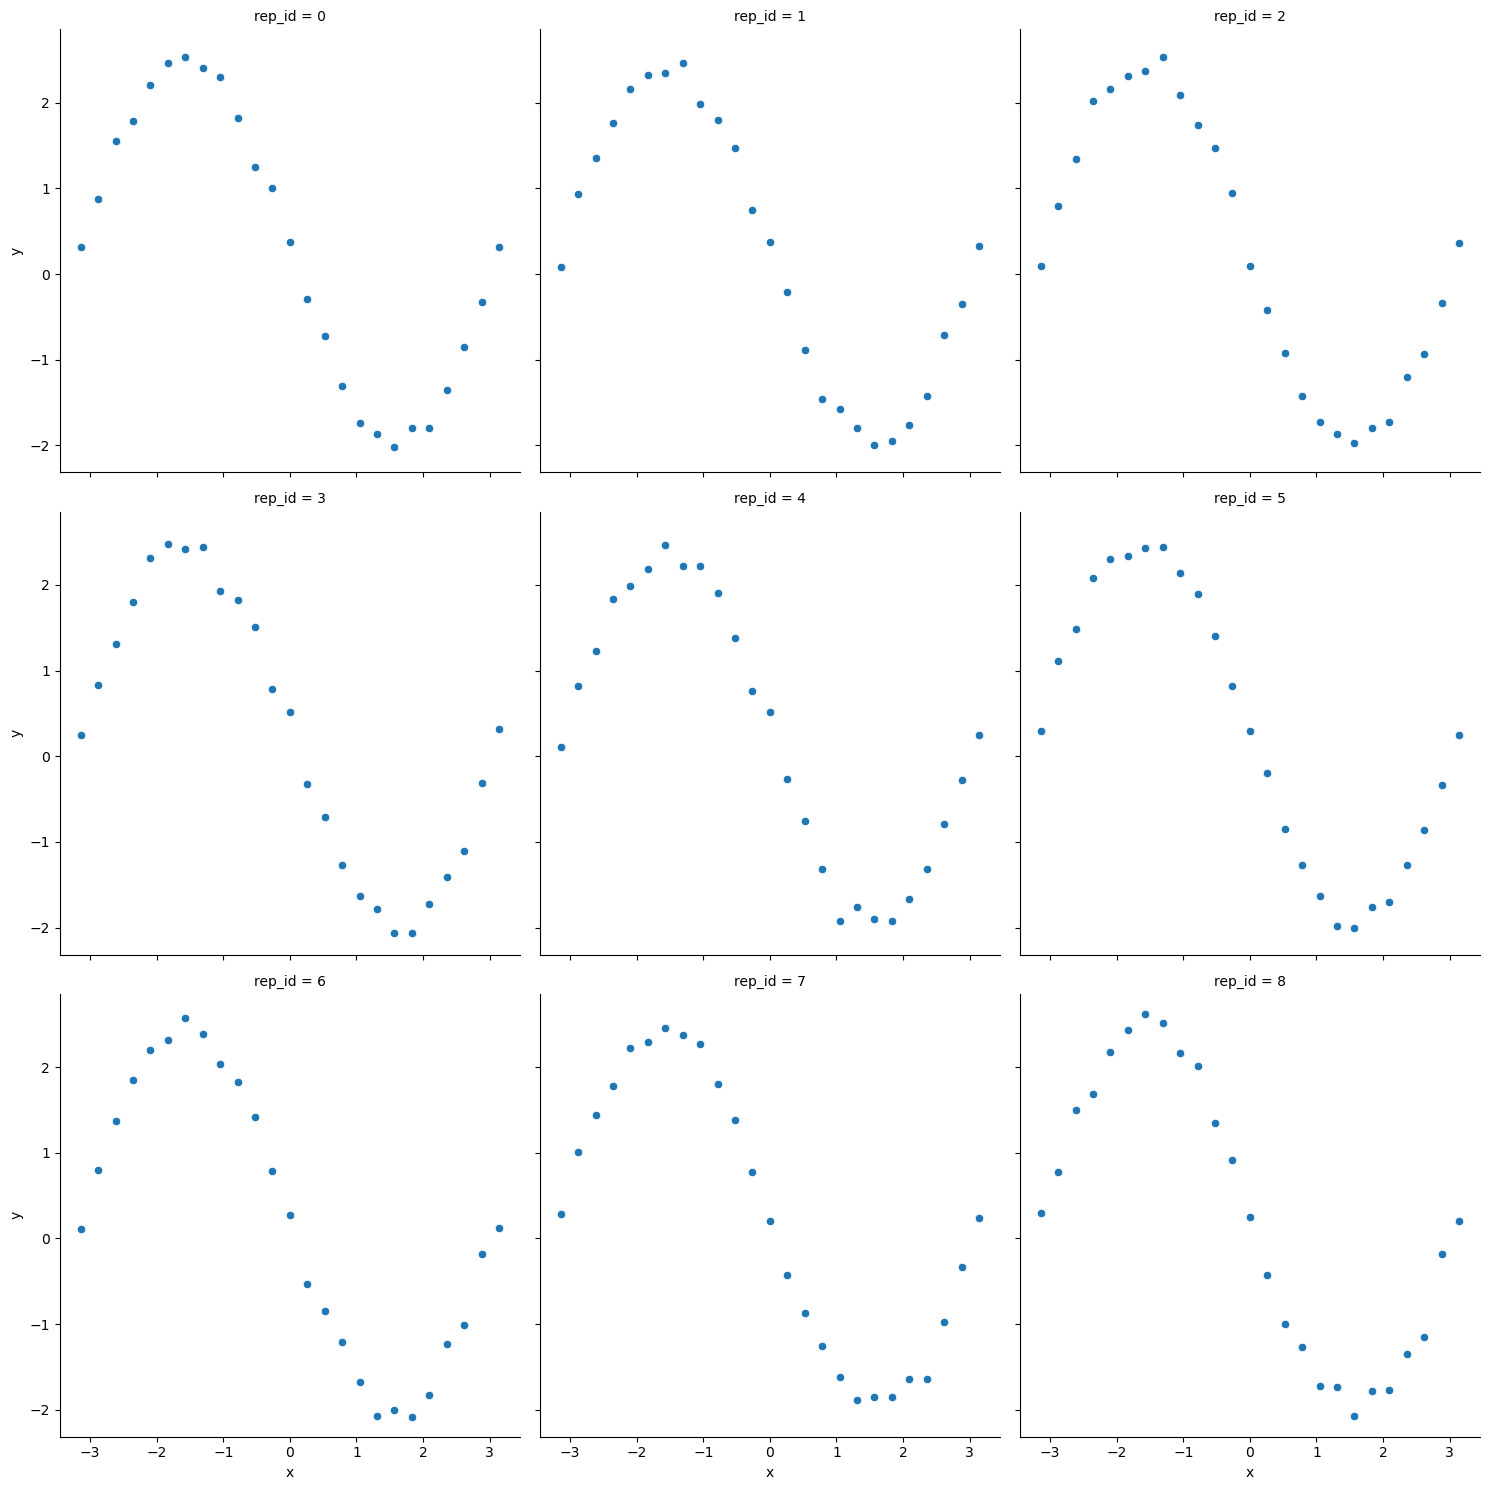

In [19]:
sns.relplot(data = study_9_df, x='x', y='y', kind='scatter', col='rep_id', col_wrap=3)
plt.show()

We can SUMMARIZE by calculating the **AVERAGE** output at each INPUT locations!!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


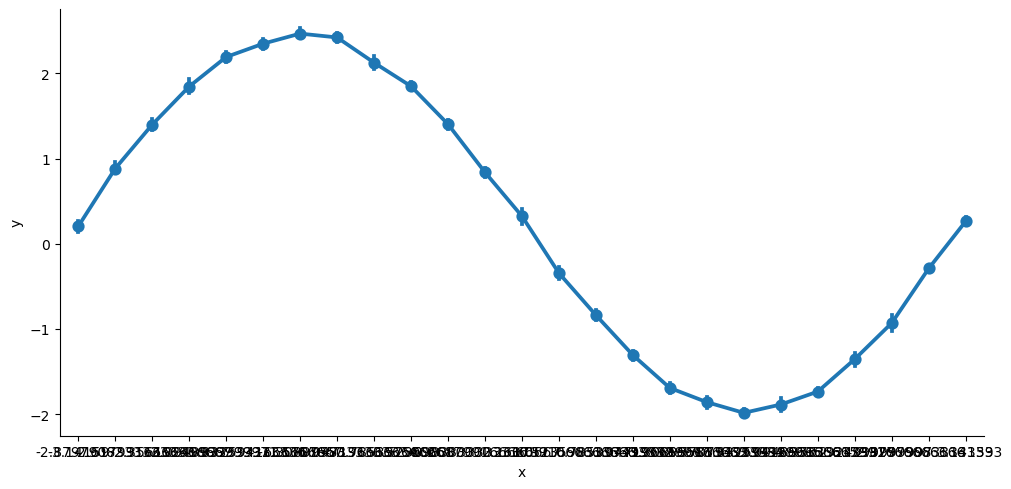

In [21]:
sns.catplot( data = study_9_df, x='x', y='y', kind='point', aspect=2)
plt.show()

Replicate the process 500 times!!!

In [22]:
study_500_list = []
for ix in range(500):
    study_500_list.append( generate_lm_sin( ix, df_sin.x,
                                         b0_sin, b1_sin,
                                         sigma_sin))

In [23]:
study_500_df = pd.concat( study_500_list, ignore_index=True )

visualize the CONDITIONAL DISTRIBUTION of 'y' **GIVEN** 'x'

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


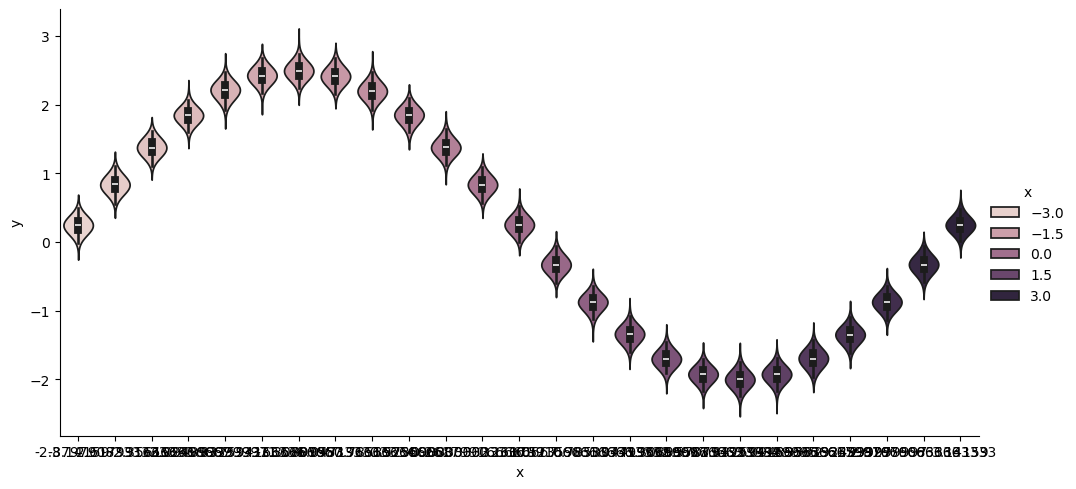

In [27]:
sns.catplot( data = study_500_df, x='x', y='y', kind='violin', hue='x', aspect=2, bw_method=1)
plt.show()

## Why does this matter??

Far too often people will think a linear model or LINEAR REGRESSION only applies if they see a LINEAR TREND!!!

But that is NOT true!!!

You do NOT need a jump streight to NEURAL NETWORK, DEEP LEANERS, or Gradient Boosted Trees!!!

Very often, you just need to derive FEATURES from your INPUTS that are NON-LINEAR functions!!! You can then FIT linear models given those new FEATURES!!!